# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## Notebook P3-01: Respiratory Rate Exploration

Can respiratory rate be estimated from CRVSE's facial rPPG
signals using classical spectral methods?

## Imports and Setup 

In [3]:
from pathlib import Path
import numpy as np
import matplotlib, h5py, collections, random, inspect
from scipy.signal import detrend as linear_detrend, hilbert
from scipy.stats import pearsonr, spearmanr
matplotlib.use('TkAgg') 
import matplotlib.pyplot as plt
# Paths
REPO_ROOT = Path.cwd().parent
H5_PATH = REPO_ROOT / "Data" / "rppg_ensemble" / "ubfc_rppg_ensemble.h5"

assert H5_PATH.exists(), f"Expected file not found: {H5_PATH}"
print(f"H5_PATH resolved to: {H5_PATH}")

# Frequency bands
RESP_LOW_HZ, RESP_HIGH_HZ = 0.10, 0.50 # 6-30 breaths/min
CARDIAC_LOW_HZ, CARDIAC_HIGH_HZ = 0.70, 3.50  # 42-210 bpm

RSA_RESAMPLE_FS = 4.0
plt.rcParams["figure.dpi"] = 110

H5_PATH resolved to: D:\code\QualityPhys - CRVSE Project\Data\rppg_ensemble\ubfc_rppg_ensemble.h5


## Is a respiration ground truth recoverable?

**What we are testing**

Whether respiratory sinus arrhythmia (RSA) - breathing's fingerprint in beat-to-beat heart timing - gives a trustworthy respiratory-rate reference on
UBFC-rPPG, before any attempt is made to extract breathing from the face.

**Why this matters**

The contact PPG stored as `reference_signal` was bandpassed 0.5-8.0 Hz during preprocessing (see `NB_P2_06_MCD-rPPG_FrontalCam_Ensemble.ipynb`), which removes most respiratory content from the waveform itself. Breathing also modulates the *timing* of heartbeats, and that timing survives untouched in `rr_intervals`.RSA is therefore the candidate ground-truth route, not the reference waveform.

Without a trustworthy reference, no facial extraction result can be checked against anything, so this has to be settled first.


recording   hr_mean  rsa_raw  rsa_dtr  ref_raw  ref_dtr  lowest_bin
subject1      106.7     28.4     28.4     23.8     23.8         7.1
subject10     109.8      6.3      6.3      8.9      8.9         6.3
subject11     122.0      6.3      6.3     29.8     29.8         6.3
subject12      66.0     10.8     10.8      6.1      6.1         6.3
subject13     107.1      6.3      6.3      7.1      7.1         6.3
subject14      80.4      8.2      8.2      6.2      6.2         6.4
subject15     115.8     11.7     11.7      6.2      6.2         6.3
subject16      91.8      9.0      9.0      9.6      9.6         6.3


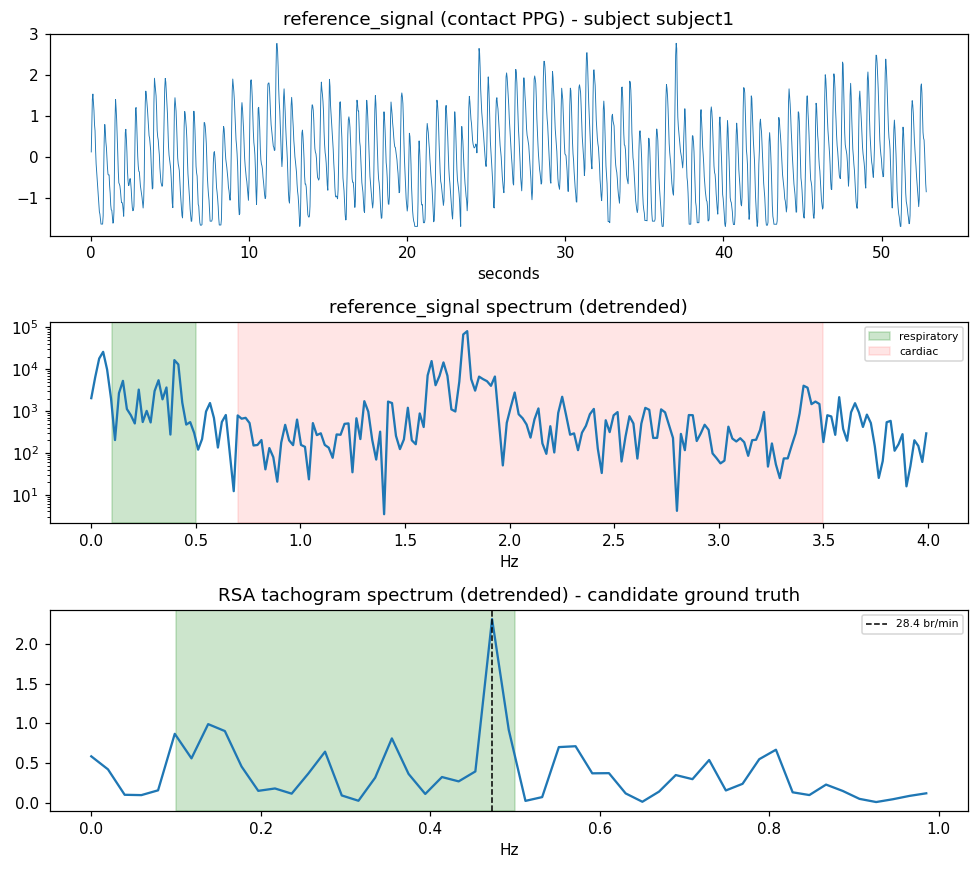

In [4]:
%matplotlib inline
def hann_power_spectrum(signal, fs, remove_trend=True):
    """Computes a one-sided Hann-windowed power spectrum, detrending or mean-removing first."""
    signal = np.atleast_1d(np.asarray(signal, dtype=np.float64))
    if signal.size < 8:
        return np.array([]), np.array([])
    signal = linear_detrend(signal, type="linear") if remove_trend else signal - np.mean(signal)
    window = np.hanning(len(signal))
    power = np.abs(np.fft.rfft(signal * window)) ** 2
    freqs = np.fft.rfftfreq(len(signal), d=1.0 / fs)
    return freqs, power


def band_peak(freqs, power, low, high):
    """Returns the peak frequency (Hz) and its share of band power inside [low, high]."""
    if freqs.size == 0:
        return None, None
    mask = (freqs >= low) & (freqs <= high)
    if not np.any(mask):
        return None, None
    band_freqs, band_power = freqs[mask], power[mask]
    total = float(np.sum(band_power))
    if total <= 0:
        return None, None
    idx = int(np.argmax(band_power))
    return float(band_freqs[idx]), float(band_power[idx] / total)


def lowest_band_bin_hz(freqs, low):
    """Returns the lowest available FFT bin frequency at or above `low`. Diagnostic only."""
    above = freqs[freqs >= low]
    return float(above[0]) if above.size else float("nan")


def find_recording_groups(h5, needs=("rr_intervals", "reference_signal"), limit=8):
    """Walks the file and returns group paths that contain the needed datasets."""
    found = []

    def visit(name, obj):
        if isinstance(obj, h5py.Group) and all(key in obj for key in needs):
            found.append(name)

    h5.visititems(visit)
    return found[:limit]


def rsa_tachogram(rr_raw, resample_fs=RSA_RESAMPLE_FS):
    """Converts beat-to-beat intervals into a uniformly sampled RSA signal, or (None, None) on failure."""
    rr = np.asarray(rr_raw, dtype=np.float64)
    rr = rr[np.isfinite(rr) & (rr > 0)]
    if len(rr) < 8:
        return None, None
    rr_s = rr / 1000.0 if np.median(rr) > 20 else rr  # ms vs seconds
    beat_times = np.cumsum(rr_s)
    beat_times -= beat_times[0]
    duration = float(beat_times[-1])
    n_samples = int(duration * resample_fs)
    if n_samples < 16:
        return None, None
    grid = np.linspace(0.0, duration, n_samples)
    return np.interp(grid, beat_times, rr_s), resample_fs


def analyze_recording(name, group):
    """Computes raw and detrended RSA and reference-signal respiratory-band estimates for one recording."""
    fps = float(group.attrs.get("fps", 30.0))
    hr_mean = float(group.attrs.get("hr_mean", float("nan")))
    ref = np.asarray(group["reference_signal"], dtype=np.float64)

    f_ref_raw, p_ref_raw = hann_power_spectrum(ref, fps, remove_trend=False)
    f_ref_dtr, p_ref_dtr = hann_power_spectrum(ref, fps, remove_trend=True)
    ref_raw_hz, _ = band_peak(f_ref_raw, p_ref_raw, RESP_LOW_HZ, RESP_HIGH_HZ)
    ref_dtr_hz, _ = band_peak(f_ref_dtr, p_ref_dtr, RESP_LOW_HZ, RESP_HIGH_HZ)

    result = {
        "name": name.split("/")[1],
        "hr_mean": hr_mean,
        "ref_raw_br_min": ref_raw_hz * 60 if ref_raw_hz else np.nan,
        "ref_dtr_br_min": ref_dtr_hz * 60 if ref_dtr_hz else np.nan,
        "rsa_raw_br_min": np.nan,
        "rsa_dtr_br_min": np.nan,
        "lowest_bin_br_min": np.nan,
        "_ref": ref,
        "_fps": fps,
        "_f_ref_dtr": f_ref_dtr,
        "_p_ref_dtr": p_ref_dtr,
        "_f_rsa_dtr": None,
        "_p_rsa_dtr": None,
    }

    sig, rsa_fs = rsa_tachogram(np.asarray(group["rr_intervals"]))
    if sig is not None:
        f_rsa_raw, p_rsa_raw = hann_power_spectrum(sig, rsa_fs, remove_trend=False)
        f_rsa_dtr, p_rsa_dtr = hann_power_spectrum(sig, rsa_fs, remove_trend=True)
        rsa_raw_hz, _ = band_peak(f_rsa_raw, p_rsa_raw, RESP_LOW_HZ, RESP_HIGH_HZ)
        rsa_dtr_hz, _ = band_peak(f_rsa_dtr, p_rsa_dtr, RESP_LOW_HZ, RESP_HIGH_HZ)
        result.update(
            rsa_raw_br_min=rsa_raw_hz * 60 if rsa_raw_hz else np.nan,
            rsa_dtr_br_min=rsa_dtr_hz * 60 if rsa_dtr_hz else np.nan,
            lowest_bin_br_min=lowest_band_bin_hz(f_rsa_raw, RESP_LOW_HZ) * 60,
            _f_rsa_dtr=f_rsa_dtr,
            _p_rsa_dtr=p_rsa_dtr,
        )

    return result


with h5py.File(H5_PATH, "r") as h5:
    groups = find_recording_groups(h5)
    results = [analyze_recording(name, h5[name]) for name in groups]

print(f"{'recording':<10}{'hr_mean':>9}{'rsa_raw':>9}{'rsa_dtr':>9}"
      f"{'ref_raw':>9}{'ref_dtr':>9}{'lowest_bin':>12}")
for r in results:
    print(f"{r['name']:<10}{r['hr_mean']:>9.1f}{r['rsa_raw_br_min']:>9.1f}"
          f"{r['rsa_dtr_br_min']:>9.1f}{r['ref_raw_br_min']:>9.1f}"
          f"{r['ref_dtr_br_min']:>9.1f}{r['lowest_bin_br_min']:>12.1f}")

# Detailed plot for one recording that has a valid RSA tachogram.
example = next(r for r in results if r["_f_rsa_dtr"] is not None)

fig, axes = plt.subplots(3, 1, figsize=(9, 8))

t = np.arange(len(example["_ref"])) / example["_fps"]
axes[0].plot(t, example["_ref"], lw=0.6)
axes[0].set_title(f"reference_signal (contact PPG) - subject {example['name']}")
axes[0].set_xlabel("seconds")

f_ref, p_ref = example["_f_ref_dtr"], example["_p_ref_dtr"]
mask_ref = f_ref <= 4.0
axes[1].semilogy(f_ref[mask_ref], p_ref[mask_ref])
axes[1].axvspan(RESP_LOW_HZ, RESP_HIGH_HZ, color="green", alpha=0.2, label="respiratory")
axes[1].axvspan(CARDIAC_LOW_HZ, CARDIAC_HIGH_HZ, color="red", alpha=0.1, label="cardiac")
axes[1].set_title("reference_signal spectrum (detrended)")
axes[1].set_xlabel("Hz")
axes[1].legend(fontsize=7)

f_rsa, p_rsa = example["_f_rsa_dtr"], example["_p_rsa_dtr"]
mask_rsa = f_rsa <= 1.0
axes[2].plot(f_rsa[mask_rsa], p_rsa[mask_rsa])
axes[2].axvspan(RESP_LOW_HZ, RESP_HIGH_HZ, color="green", alpha=0.2)
if np.isfinite(example["rsa_dtr_br_min"]):
    axes[2].axvline(example["rsa_dtr_br_min"] / 60.0, color="k", ls="--", lw=1,
                     label=f"{example['rsa_dtr_br_min']:.1f} br/min")
    axes[2].legend(fontsize=7)
axes[2].set_title("RSA tachogram spectrum (detrended) - candidate ground truth")
axes[2].set_xlabel("Hz")

fig.tight_layout()
plt.show()

## separating the Mayer-wave/LF rhythm from the respiratory HF band

**What we are testing**

Whether the repeated ~6.3 breaths/min estimate is the well-known baroreflex-driven "Mayer wave," a real autonomic oscillation near 0.1 Hz that is unrelated to breathing, rather than a defect in the extraction. The standard HRV convention splits this region into LF (0.04-0.15 Hz, baroreflex/Mayer wave) and HF (0.15-0.40 Hz, the band actually driven by respiration).

**Why this matters**

If the wide 0.10-0.50 Hz band lets a strong non-respiratory rhythm win the peak search, RSA will look unusable even when a genuine respiratory signal is present. Narrowing to the HF sub-band, and reporting the LF/HF power ratio as a diagnostic, should separate the two.


In [5]:
LF_LOW_HZ, LF_HIGH_HZ = 0.10, 0.15   # baroreflex / Mayer wave, not respiratory
HF_LOW_HZ, HF_HIGH_HZ = 0.15, 0.40   # respiration-driven RSA band

print(f"{'recording':<10}{'wide_peak':>10}{'HF_peak':>9}{'LF_peak':>9}{'LF/HF_pwr':>10}")

for r in results:
    f_rsa, p_rsa = r["_f_rsa_dtr"], r["_p_rsa_dtr"]
    if f_rsa is None:
        print(f"{r['name']:<10}{'--':>10}{'--':>9}{'--':>9}{'--':>10}")
        continue

    hf_hz, _ = band_peak(f_rsa, p_rsa, HF_LOW_HZ, HF_HIGH_HZ)
    lf_hz, _ = band_peak(f_rsa, p_rsa, LF_LOW_HZ, LF_HIGH_HZ)

    lf_mask = (f_rsa >= LF_LOW_HZ) & (f_rsa < LF_HIGH_HZ)
    hf_mask = (f_rsa >= HF_LOW_HZ) & (f_rsa <= HF_HIGH_HZ)
    lf_power = float(np.sum(p_rsa[lf_mask]))
    hf_power = float(np.sum(p_rsa[hf_mask]))
    lf_hf_ratio = lf_power / hf_power if hf_power > 0 else np.nan

    print(f"{r['name']:<10}{r['rsa_dtr_br_min']:>10.1f}"
          f"{(hf_hz * 60 if hf_hz else np.nan):>9.1f}"
          f"{(lf_hz * 60 if lf_hz else np.nan):>9.1f}"
          f"{lf_hf_ratio:>10.2f}")

print("\nReading: if HF_peak now lands in a plausible 9-24 br/min range and differs")
print("from the old wide_peak for the subjects previously stuck at 6.3, the LF rhythm")
print("was the confound. A high LF/HF ratio (>>1) means the Mayer wave dominates that")
print("recording's spectrum and its HF peak should be trusted less.")

recording  wide_peak  HF_peak  LF_peak LF/HF_pwr
subject1        28.4      9.5      8.3      0.34
subject10        6.3     13.6      6.3      0.29
subject11        6.3     12.6      6.3      0.64
subject12       10.8     10.8      9.0      0.20
subject13        6.3     10.9      6.3      0.34
subject14        8.2      9.1      8.2      0.85
subject15       11.7     11.7      8.1      0.14
subject16        9.0     14.3      9.0      0.33

Reading: if HF_peak now lands in a plausible 9-24 br/min range and differs
from the old wide_peak for the subjects previously stuck at 6.3, the LF rhythm
was the confound. A high LF/HF ratio (>>1) means the Mayer wave dominates that
recording's spectrum and its HF peak should be trusted less.


In [6]:
RESP_ONLY_LOW_HZ = 0.15  # excludes the Mayer-wave/LF zone found above; keeps RESP_HIGH_HZ (0.50) from setup

print(f"{'recording':<10}{'hr_mean':>9}{'HF_0.40_peak':>13}{'HF_0.50_peak':>13}{'LF/HF_pwr':>10}")

for r in results:
    f_rsa, p_rsa = r["_f_rsa_dtr"], r["_p_rsa_dtr"]
    if f_rsa is None:
        print(f"{r['name']:<10}{r['hr_mean']:>9.1f}{'--':>13}{'--':>13}{'--':>10}")
        continue

    hf40_hz, _ = band_peak(f_rsa, p_rsa, HF_LOW_HZ, HF_HIGH_HZ)       # 0.15-0.40, prior cell
    hf50_hz, _ = band_peak(f_rsa, p_rsa, RESP_ONLY_LOW_HZ, RESP_HIGH_HZ)  # 0.15-0.50

    lf_mask = (f_rsa >= LF_LOW_HZ) & (f_rsa < LF_HIGH_HZ)
    hf_mask = (f_rsa >= RESP_ONLY_LOW_HZ) & (f_rsa <= RESP_HIGH_HZ)
    lf_power = float(np.sum(p_rsa[lf_mask]))
    hf_power = float(np.sum(p_rsa[hf_mask]))
    lf_hf_ratio = lf_power / hf_power if hf_power > 0 else np.nan

    print(f"{r['name']:<10}{r['hr_mean']:>9.1f}"
          f"{(hf40_hz * 60 if hf40_hz else np.nan):>13.1f}"
          f"{(hf50_hz * 60 if hf50_hz else np.nan):>13.1f}"
          f"{lf_hf_ratio:>10.2f}")

print("\nReading: if HF_0.50_peak reverts subject1 toward ~28 br/min while the other")
print("subjects keep the plausible, differentiated values from the previous cell,")
print("0.15-0.50 Hz is the right respiratory band for this cohort: it drops the")
print("Mayer wave without truncating genuinely fast breathers.")

recording   hr_mean HF_0.40_peak HF_0.50_peak LF/HF_pwr
subject1      106.7          9.5         28.4      0.18
subject10     109.8         13.6         25.4      0.16
subject11     122.0         12.6         12.6      0.44
subject12      66.0         10.8         10.8      0.18
subject13     107.1         10.9         24.5      0.28
subject14      80.4          9.1          9.1      0.80
subject15     115.8         11.7         11.7      0.11
subject16      91.8         14.3         14.3      0.26

Reading: if HF_0.50_peak reverts subject1 toward ~28 br/min while the other
subjects keep the plausible, differentiated values from the previous cell,
0.15-0.50 Hz is the right respiratory band for this cohort: it drops the
Mayer wave without truncating genuinely fast breathers.


recording   hr_mean  HR/4_pred HF_0.50_peak  peak_frac
subject1      106.7       26.7         28.4      0.265
subject10     109.8       27.5         25.4      0.085
subject13     107.1       26.8         24.5      0.103


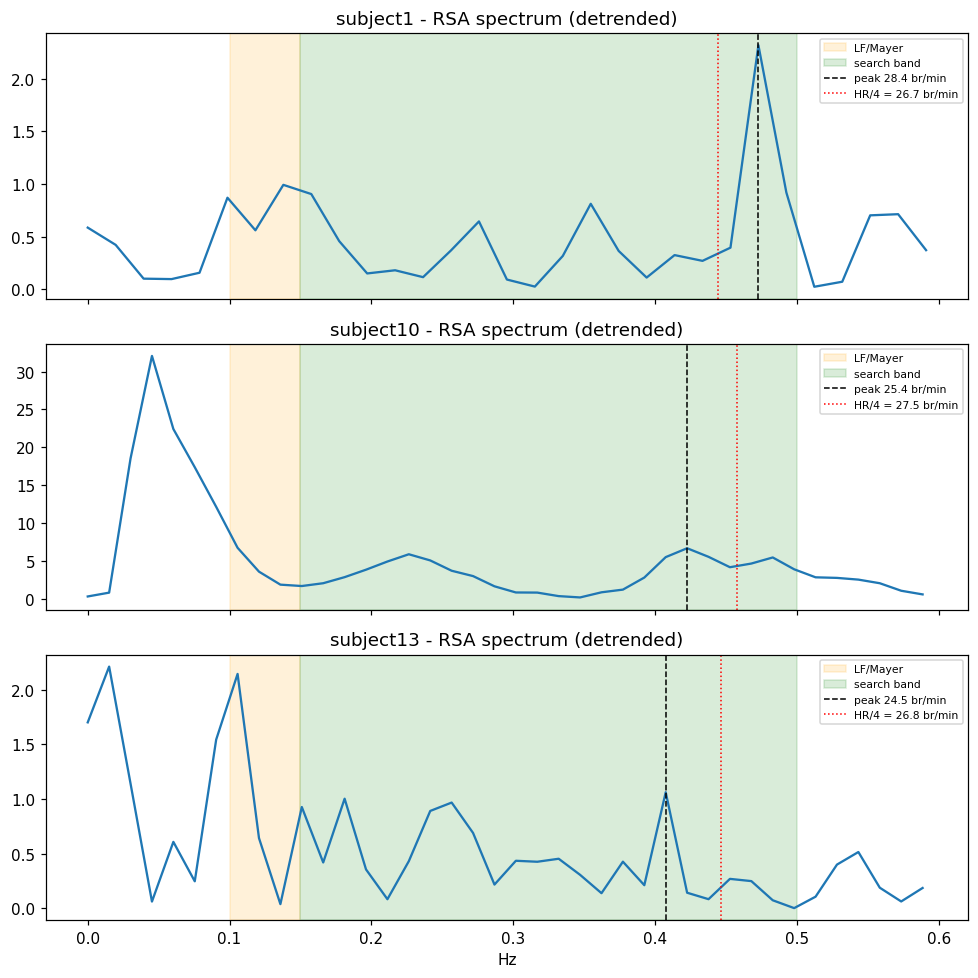


Reading: a peak visibly separated from the red HR/4 marker, with a peak_frac
comparable to the confident subjects from the earlier table (0.11-0.85 range),
supports genuine fast breathing. A peak sitting right on top of the HR/4 marker,
or a peak_frac no higher than what noise alone would produce in a ~7-bin-wide
window, supports a beat-detection subharmonic artifact instead.


In [7]:
CHECK_NAMES = ["subject1", "subject10", "subject13"]  # peaks that moved when the band widened to 0.50 Hz

fig, axes = plt.subplots(len(CHECK_NAMES), 1, figsize=(9, 3 * len(CHECK_NAMES)), sharex=True)

print(f"{'recording':<10}{'hr_mean':>9}{'HR/4_pred':>11}{'HF_0.50_peak':>13}{'peak_frac':>11}")

for ax, name in zip(axes, CHECK_NAMES):
    r = next(item for item in results if item["name"] == name)
    f_rsa, p_rsa = r["_f_rsa_dtr"], r["_p_rsa_dtr"]

    peak_hz, peak_frac = band_peak(f_rsa, p_rsa, RESP_ONLY_LOW_HZ, RESP_HIGH_HZ)
    hr4_pred = r["hr_mean"] / 4.0

    print(f"{name:<10}{r['hr_mean']:>9.1f}{hr4_pred:>11.1f}"
          f"{(peak_hz * 60 if peak_hz else np.nan):>13.1f}"
          f"{(peak_frac if peak_frac else np.nan):>11.3f}")

    mask = f_rsa <= 0.6
    ax.plot(f_rsa[mask], p_rsa[mask])
    ax.axvspan(LF_LOW_HZ, LF_HIGH_HZ, color="orange", alpha=0.15, label="LF/Mayer")
    ax.axvspan(RESP_ONLY_LOW_HZ, RESP_HIGH_HZ, color="green", alpha=0.15, label="search band")
    if peak_hz:
        ax.axvline(peak_hz, color="k", ls="--", lw=1, label=f"peak {peak_hz * 60:.1f} br/min")
    ax.axvline(hr4_pred / 60.0, color="red", ls=":", lw=1, label=f"HR/4 = {hr4_pred:.1f} br/min")
    ax.set_title(f"{name} - RSA spectrum (detrended)")
    ax.legend(fontsize=7, loc="upper right")

axes[-1].set_xlabel("Hz")
fig.tight_layout()
plt.show()

print("\nReading: a peak visibly separated from the red HR/4 marker, with a peak_frac")
print("comparable to the confident subjects from the earlier table (0.11-0.85 range),")
print("supports genuine fast breathing. A peak sitting right on top of the HR/4 marker,")
print("or a peak_frac no higher than what noise alone would produce in a ~7-bin-wide")
print("window, supports a beat-detection subharmonic artifact instead.")

In [8]:
FRAC_CONFIDENT_THRESHOLD = 0.15  # provisional; 1/7 ~ 0.143 is the flat-noise baseline for this band width

print(f"{'recording':<10}{'hr_mean':>9}{'RR_br_min':>11}{'peak_frac':>11}{'confidence':>12}")

ground_truth = []

for r in results:
    f_rsa, p_rsa = r["_f_rsa_dtr"], r["_p_rsa_dtr"]
    if f_rsa is None:
        print(f"{r['name']:<10}{r['hr_mean']:>9.1f}{'--':>11}{'--':>11}{'no_rr_intervals':>12}")
        continue

    peak_hz, peak_frac = band_peak(f_rsa, p_rsa, RESP_ONLY_LOW_HZ, RESP_HIGH_HZ)
    rr_br_min = peak_hz * 60 if peak_hz else np.nan
    frac = peak_frac if peak_frac is not None else np.nan
    confidence = "confident" if (np.isfinite(frac) and frac >= FRAC_CONFIDENT_THRESHOLD) else "uncertain"

    ground_truth.append({
        "name": r["name"], "hr_mean": r["hr_mean"],
        "rr_br_min": rr_br_min, "peak_frac": frac, "confidence": confidence,
    })

    print(f"{r['name']:<10}{r['hr_mean']:>9.1f}{rr_br_min:>11.1f}{frac:>11.3f}{confidence:>12}")

n_confident = sum(1 for g in ground_truth if g["confidence"] == "confident")
print(f"\n{n_confident}/{len(ground_truth)} recordings pass the provisional confidence threshold "
      f"(peak_frac >= {FRAC_CONFIDENT_THRESHOLD}).")
print("This is the working RSA ground-truth table. Experiment 2 will compare facial estimates")
print("only against the 'confident' subset; the 'uncertain' subset stays visible but unused")
print("for judging agreement.")

recording   hr_mean  RR_br_min  peak_frac  confidence
subject1      106.7       28.4      0.265   confident
subject10     109.8       25.4      0.085   uncertain
subject11     122.0       12.6      0.089   uncertain
subject12      66.0       10.8      0.182   confident
subject13     107.1       24.5      0.103   uncertain
subject14      80.4        9.1      0.291   confident
subject15     115.8       11.7      0.064   uncertain
subject16      91.8       14.3      0.106   uncertain

3/8 recordings pass the provisional confidence threshold (peak_frac >= 0.15).
This is the working RSA ground-truth table. Experiment 2 will compare facial estimates
only against the 'confident' subset; the 'uncertain' subset stays visible but unused
for judging agreement.


In [9]:
def band_peak_neighborhood(freqs, power, low, high, neighborhood_bins=1):
    """
    Returns the peak frequency (Hz) and its neighborhood share of band power inside [low, high].

    Matches the peak-to-band convention used in app/live_hr_demo/rppg/sqi.py
    (estimate_spectral_sqi): power is summed over the peak bin plus its
    immediate neighbors rather than the single peak bin alone, to account for
    spectral leakage in a short, coarsely resolved window.
    """
    if freqs.size == 0:
        return None, None
    mask = (freqs >= low) & (freqs <= high)
    if not np.any(mask):
        return None, None
    band_indices = np.where(mask)[0]
    band_power = power[band_indices]
    total = float(np.sum(band_power))
    if total <= 0:
        return None, None
    local_peak_idx = int(np.argmax(band_power))
    peak_idx = int(band_indices[local_peak_idx])
    left_idx = max(band_indices[0], peak_idx - neighborhood_bins)
    right_idx = min(band_indices[-1], peak_idx + neighborhood_bins)
    peak_power = float(np.sum(power[left_idx : right_idx + 1]))
    return float(freqs[peak_idx]), float(peak_power / total)


print(f"{'recording':<10}{'hr_mean':>9}{'RR_br_min':>11}{'frac_1bin':>11}{'frac_3bin':>11}{'confidence':>12}")

ground_truth_v2 = []

for r in results:
    f_rsa, p_rsa = r["_f_rsa_dtr"], r["_p_rsa_dtr"]
    if f_rsa is None:
        print(f"{r['name']:<10}{r['hr_mean']:>9.1f}{'--':>11}{'--':>11}{'--':>11}{'no_rr_intervals':>12}")
        continue

    peak_hz_1, frac_1 = band_peak(f_rsa, p_rsa, RESP_ONLY_LOW_HZ, RESP_HIGH_HZ)
    peak_hz_3, frac_3 = band_peak_neighborhood(f_rsa, p_rsa, RESP_ONLY_LOW_HZ, RESP_HIGH_HZ, neighborhood_bins=1)

    rr_br_min = peak_hz_3 * 60 if peak_hz_3 else np.nan
    frac_1v = frac_1 if frac_1 is not None else np.nan
    frac_3v = frac_3 if frac_3 is not None else np.nan
    confidence = "confident" if (np.isfinite(frac_3v) and frac_3v >= FRAC_CONFIDENT_THRESHOLD) else "uncertain"

    ground_truth_v2.append({
        "name": r["name"], "hr_mean": r["hr_mean"],
        "rr_br_min": rr_br_min, "peak_frac_3bin": frac_3v, "confidence": confidence,
    })

    print(f"{r['name']:<10}{r['hr_mean']:>9.1f}{rr_br_min:>11.1f}"
          f"{frac_1v:>11.3f}{frac_3v:>11.3f}{confidence:>12}")

n_confident = sum(1 for g in ground_truth_v2 if g["confidence"] == "confident")
print(f"\n{n_confident}/{len(ground_truth_v2)} recordings pass peak_frac_3bin >= {FRAC_CONFIDENT_THRESHOLD}.")
print("Compare frac_1bin to frac_3bin per subject: a genuine narrowband peak with some")
print("leakage into neighboring bins should gain noticeably from neighborhood-summing.")
print("A noise pick with no elevated neighbors should barely change.")

recording   hr_mean  RR_br_min  frac_1bin  frac_3bin  confidence
subject1      106.7       28.4      0.265      0.415   confident
subject10     109.8       25.4      0.085      0.227   confident
subject11     122.0       12.6      0.089      0.223   confident
subject12      66.0       10.8      0.182      0.445   confident
subject13     107.1       24.5      0.103      0.138   uncertain
subject14      80.4        9.1      0.291      0.398   confident
subject15     115.8       11.7      0.064      0.180   confident
subject16      91.8       14.3      0.106      0.259   confident

7/8 recordings pass peak_frac_3bin >= 0.15.
Compare frac_1bin to frac_3bin per subject: a genuine narrowband peak with some
leakage into neighboring bins should gain noticeably from neighborhood-summing.
A noise pick with no elevated neighbors should barely change.


In [10]:
def uniform_baseline_fraction(freqs, low, high, neighborhood_bins=1):
    """
    Returns the fraction a flat, uniform spectrum would produce for a
    (2*neighborhood_bins+1)-bin sum inside [low, high], given the actual
    number of bins present for this recording's duration and resample rate.

    Used to normalize peak_frac against the correct noise floor, rather than
    an assumed bin count borrowed from a differently sized band.
    """
    mask = (freqs >= low) & (freqs <= high)
    n_bins = int(np.sum(mask))
    if n_bins == 0:
        return float("nan")
    return (2 * neighborhood_bins + 1) / n_bins


print(f"{'recording':<10}{'RR_br_min':>11}{'frac_3bin':>11}{'baseline':>10}{'ratio':>8}{'tier':>10}")

ground_truth_v3 = []

for r in results:
    f_rsa, p_rsa = r["_f_rsa_dtr"], r["_p_rsa_dtr"]
    if f_rsa is None:
        print(f"{r['name']:<10}{'--':>11}{'--':>11}{'--':>10}{'--':>8}{'no_rr':>10}")
        continue

    peak_hz, frac_3 = band_peak_neighborhood(f_rsa, p_rsa, RESP_ONLY_LOW_HZ, RESP_HIGH_HZ, neighborhood_bins=1)
    baseline = uniform_baseline_fraction(f_rsa, RESP_ONLY_LOW_HZ, RESP_HIGH_HZ, neighborhood_bins=1)

    rr_br_min = peak_hz * 60 if peak_hz else np.nan
    frac_v = frac_3 if frac_3 is not None else np.nan
    ratio = frac_v / baseline if (np.isfinite(frac_v) and baseline > 0) else np.nan

    if not np.isfinite(ratio):
        tier = "no_signal"
    elif ratio >= 2.5:
        tier = "strong"
    elif ratio >= 1.5:
        tier = "moderate"
    else:
        tier = "weak"

    ground_truth_v3.append({
        "name": r["name"], "rr_br_min": rr_br_min,
        "ratio_to_baseline": ratio, "tier": tier,
    })

    print(f"{r['name']:<10}{rr_br_min:>11.1f}{frac_v:>11.3f}{baseline:>10.3f}{ratio:>8.2f}{tier:>10}")

print("\n'ratio' = frac_3bin / baseline, i.e. how many times above flat-noise expectation")
print("this recording's peak sits, properly accounting for its actual bin count.")
print("This replaces the earlier 0.15 absolute threshold, which was miscalibrated.")

recording   RR_br_min  frac_3bin  baseline   ratio      tier
subject1         28.4      0.415     0.167    2.49  moderate
subject10        25.4      0.227     0.125    1.82  moderate
subject11        12.6      0.223     0.130    1.71  moderate
subject12        10.8      0.445     0.130    3.41    strong
subject13        24.5      0.138     0.125    1.10      weak
subject14         9.1      0.398     0.125    3.18    strong
subject15        11.7      0.180     0.125    1.44      weak
subject16        14.3      0.259     0.130    1.99  moderate

'ratio' = frac_3bin / baseline, i.e. how many times above flat-noise expectation
this recording's peak sits, properly accounting for its actual bin count.
This replaces the earlier 0.15 absolute threshold, which was miscalibrated.


In [11]:
N_SURROGATES = 500
rng = np.random.default_rng(42)  # reproducible

print(f"{'recording':<10}{'RR_br_min':>11}{'observed':>10}{'null_mean':>11}{'null_p95':>10}{'p_value':>9}")

surrogate_results = []

with h5py.File(H5_PATH, "r") as h5:
    for name in groups:
        group = h5[name]
        sig, rsa_fs = rsa_tachogram(np.asarray(group["rr_intervals"]))
        if sig is None:
            continue

        detrended = linear_detrend(sig, type="linear")

        f_real, p_real = hann_power_spectrum(sig, rsa_fs, remove_trend=True)
        peak_hz_real, frac_real = band_peak_neighborhood(
            f_real, p_real, RESP_ONLY_LOW_HZ, RESP_HIGH_HZ, neighborhood_bins=1
        )

        null_fracs = np.empty(N_SURROGATES)
        for i in range(N_SURROGATES):
            shuffled = rng.permutation(detrended)
            f_null, p_null = hann_power_spectrum(shuffled, rsa_fs, remove_trend=False)
            _, frac_null = band_peak_neighborhood(
                f_null, p_null, RESP_ONLY_LOW_HZ, RESP_HIGH_HZ, neighborhood_bins=1
            )
            null_fracs[i] = frac_null if frac_null is not None else np.nan

        null_fracs = null_fracs[np.isfinite(null_fracs)]
        p_value = float(np.mean(null_fracs >= frac_real)) if frac_real is not None else np.nan

        subj_name = name.split("/")[1]
        rr_br_min = peak_hz_real * 60 if peak_hz_real else np.nan

        surrogate_results.append({"name": subj_name, "rr_br_min": rr_br_min, "p_value": p_value})

        print(f"{subj_name:<10}{rr_br_min:>11.1f}{frac_real:>10.3f}"
              f"{np.mean(null_fracs):>11.3f}{np.percentile(null_fracs, 95):>10.3f}{p_value:>9.3f}")

print("\np_value = fraction of shuffled-order surrogates whose best in-band peak fraction")
print("matched or beat the real recording's value. Low p_value (e.g. < 0.05) means the")
print("observed peak is stronger than pure chance would produce at this exact recording")
print("length -- real evidence of SOME narrowband rhythm, not proof it is specifically")
print("respiration rather than another periodic process (e.g. the Mayer wave, if it")
print("leaked past the band edge, or a cardiac subharmonic).")

recording   RR_br_min  observed  null_mean  null_p95  p_value
subject1         28.4     0.415      0.350     0.527    0.206
subject10        25.4     0.227      0.278     0.405    0.746
subject11        12.6     0.223      0.281     0.411    0.764
subject12        10.8     0.445      0.289     0.428    0.042
subject13        24.5     0.138      0.265     0.380    0.998
subject14         9.1     0.398      0.284     0.437    0.098
subject15        11.7     0.180      0.259     0.373    0.928
subject16        14.3     0.259      0.289     0.432    0.620

p_value = fraction of shuffled-order surrogates whose best in-band peak fraction
matched or beat the real recording's value. Low p_value (e.g. < 0.05) means the
observed peak is stronger than pure chance would produce at this exact recording
length -- real evidence of SOME narrowband rhythm, not proof it is specifically
respiration rather than another periodic process (e.g. the Mayer wave, if it
leaked past the band edge, or a cardiac su

## Checking MCD-rPPG's structure before reusing the validated pipeline

**What we are testing**

Whether MCD-rPPG's recordings have the same schema as UBFC-rPPG (`rr_intervals`, `reference_signal`) and are meaningfully longer, before re-running the permutation-tested RSA pipeline on them.

**Why this matters**

The permutation test above gave a clean, honest negative for UBFC-rPPG, most plausibly because ~50-70 s recordings carry too little information for this statistic to have power, compounded by an apparently aroused cohort. MCD-rPPG recordings were noted elsewhere in this project as running closer to 180 s. This should be confirmed directly, and any state/activity labels (rest vs. after-exercise) should be identified, before selecting a fair comparable subset to re-test.



In [12]:
MCD_H5_PATH = REPO_ROOT / "Data" / "rppg_ensemble" / "mcd_rppg_ensemble.h5"
assert MCD_H5_PATH.exists(), f"Expected file not found: {MCD_H5_PATH}"

def describe_group(group, name):
    """Prints the datasets and attributes of one recording group."""
    print(f"\nRecording: {name}")
    print("  attrs:", {k: group.attrs[k] for k in group.attrs})
    for key in group:
        try:
            print(f"    {key:<18} shape={group[key].shape} dtype={group[key].dtype}")
        except Exception as exc:  # noqa: BLE001
            print(f"    {key:<18} <{exc}>")

with h5py.File(MCD_H5_PATH, "r") as h5:
    mcd_groups = find_recording_groups(h5, limit=10_000)  # count everything, not just the first 8
    print(f"Total recording groups with rr_intervals + reference_signal: {len(mcd_groups)}")

    activity_counts = {}
    durations = []

    for name in mcd_groups:
        group = h5[name]
        activity = group.attrs.get("activity_id", group.attrs.get("activity_name", "unknown"))
        activity_counts[activity] = activity_counts.get(activity, 0) + 1

        fps = float(group.attrs.get("fps", 30.0))
        n_samples = len(group["reference_signal"])
        durations.append(n_samples / fps)

    print("\nActivity/state label counts:")
    for activity, count in sorted(activity_counts.items(), key=lambda item: -item[1]):
        print(f"  {activity!s:<20}{count:>6}")

    durations = np.asarray(durations)
    print(f"\nDuration (s): min={durations.min():.1f}, median={np.median(durations):.1f}, "
          f"max={durations.max():.1f}")

    # Detailed look at one example recording, same style as the very first inspection.
    example_name = mcd_groups[0]
    describe_group(h5[example_name], example_name)

Total recording groups with rr_intervals + reference_signal: 506

Activity/state label counts:
  before                 258
  after                  248

Duration (s): min=10.0, median=180.2, max=189.6

Recording: subjects/1020/recordings/after
  attrs: {'activity_id': 'after', 'activity_name': 'post_exercise', 'bm_age': np.float64(23.0), 'bm_age_tier': 'tier_3_conditioning', 'bm_age_valid': np.True_, 'bm_arterial_stiffness': np.float64(10.79), 'bm_arterial_stiffness_tier': 'tier_2_experimental', 'bm_arterial_stiffness_valid': np.True_, 'bm_bmi': np.float64(19.031141868512112), 'bm_bmi_tier': 'tier_3_conditioning', 'bm_bmi_valid': np.True_, 'bm_cholesterol': np.float64(4.3), 'bm_cholesterol_tier': 'tier_4_not_feasible', 'bm_cholesterol_valid': np.True_, 'bm_diastolic_bp': np.float64(78.0), 'bm_diastolic_bp_tier': 'tier_2_experimental', 'bm_diastolic_bp_valid': np.True_, 'bm_glycated_hb': np.float64(5.56), 'bm_glycated_hb_tier': 'tier_4_not_feasible', 'bm_glycated_hb_valid': np.True_, '

In [13]:
tier_counts = collections.Counter()
duration_by_group = {}
candidates = []

with h5py.File(MCD_H5_PATH, "r") as h5:
    for name in mcd_groups:
        group = h5[name]
        fps = float(group.attrs.get("fps", 30.0))
        n_frames = int(group.attrs.get("n_frames", len(group["reference_signal"])))
        duration_s = n_frames / fps
        duration_by_group[name] = duration_s

        rr = group.attrs.get("bm_respiratory_rate", None)
        valid = bool(group.attrs.get("bm_respiratory_rate_valid", False))
        tier = str(group.attrs.get("bm_respiratory_rate_tier", "unknown"))
        state = str(group.attrs.get("activity_id", "unknown"))

        tier_counts[tier] += 1

        if valid and tier == "tier_1_confident" and rr is not None:
            candidates.append({
                "name": name, "state": state,
                "rr_br_min": float(rr), "duration_s": duration_s,
            })

print(f"Total recordings: {len(mcd_groups)}")
print("Tier counts:", dict(tier_counts))

durations_all = np.asarray(list(duration_by_group.values()))
print(f"\nAll recordings, duration >= 150s: {int((durations_all >= 150.0).sum())}/{len(durations_all)}")

long_and_confident = [c for c in candidates if c["duration_s"] >= 150.0]
print(f"Valid + tier_1_confident + duration >= 150s: {len(long_and_confident)}")

rr_vals = np.asarray([c["rr_br_min"] for c in long_and_confident])
if len(rr_vals):
    print(f"bm_respiratory_rate in this pool: min={rr_vals.min():.1f}, "
          f"median={np.median(rr_vals):.1f}, max={rr_vals.max():.1f}")

by_state = collections.Counter(c["state"] for c in long_and_confident)
print("By state:", dict(by_state))

print("\nFirst 10 candidates (name, state, RR, duration_s):")
for c in long_and_confident[:10]:
    print(f"  {c['name']:<35}{c['state']:>8}{c['rr_br_min']:>7.1f}{c['duration_s']:>9.1f}")

Total recordings: 506
Tier counts: {'tier_1_confident': 506}

All recordings, duration >= 150s: 504/506
Valid + tier_1_confident + duration >= 150s: 504
bm_respiratory_rate in this pool: min=15.0, median=18.0, max=24.0
By state: {'before': 257, 'after': 247}

First 10 candidates (name, state, RR, duration_s):
  subjects/1020/recordings/before      before   18.0    180.0
  subjects/1035/recordings/after        after   18.0    180.1
  subjects/1035/recordings/before      before   18.0    179.0
  subjects/1091/recordings/after        after   19.0    180.5
  subjects/1091/recordings/before      before   16.0    180.6
  subjects/1113/recordings/after        after   20.0    180.6
  subjects/1115/recordings/after        after   19.0    179.5
  subjects/1149/recordings/before      before   18.0    180.1
  subjects/1156/recordings/before      before   16.0    179.7
  subjects/1180/recordings/before      before   16.0    177.9


In [17]:
RSA_SEARCH_LOW_HZ = 0.15   # excludes the Mayer-wave zone found in UBFC-rPPG
RSA_SEARCH_HIGH_HZ = 0.50

def rsa_rr_estimate(rr_ms, low=RSA_SEARCH_LOW_HZ, high=RSA_SEARCH_HIGH_HZ, resample_fs=RSA_RESAMPLE_FS):
    """Estimates respiratory rate in breaths/min from a beat-to-beat interval series.

    Builds a uniformly resampled RSA tachogram, computes its detrended Hann
    power spectrum, and returns the 3-bin-neighborhood peak frequency in
    breaths/min plus its band-power fraction. Returns (None, None) if the
    tachogram cannot be built or is too short for a spectrum.
    """
    rsa, _ = rsa_tachogram(rr_ms, resample_fs=resample_fs)
    if rsa is None:
        return None, None
    freqs, power = hann_power_spectrum(rsa, resample_fs, remove_trend=True)
    if len(freqs) == 0:
        return None, None
    peak_hz, frac = band_peak_neighborhood(freqs, power, low, high, neighborhood_bins=1)
    if peak_hz is None:
        return None, None
    return peak_hz * 60.0, frac


MCD_H5_PATH = REPO_ROOT / "Data" / "rppg_ensemble" / "mcd_rppg_ensemble.h5"


with h5py.File(MCD_H5_PATH, "r") as h5:
    rows = []
    for name, state, rr_clinical, duration_s in sample:
        rr_ms = h5[name]["rr_intervals"][:]
        rr_rsa, frac = rsa_rr_estimate(rr_ms)
        rows.append((name, state, rr_clinical, rr_rsa, frac))

print(f"{'recording':38s} {'state':8s} {'clinical':>8s} {'RSA':>7s} {'frac':>6s} {'|diff|':>7s}")
diffs = []
for name, state, rr_clinical, rr_rsa, frac in rows:
    if rr_rsa is not None:
        diff = abs(rr_rsa - rr_clinical)
        diffs.append(diff)
        print(f"{name:38s} {state:8s} {rr_clinical:8.1f} {rr_rsa:7.1f} {frac:6.2f} {diff:7.1f}")
    else:
        print(f"{name:38s} {state:8s} {rr_clinical:8.1f} {'n/a':>7s} {'n/a':>6s} {'n/a':>7s}")

n_valid = len(diffs)
print(f"\nValid RSA estimates: {n_valid}/{len(rows)}")
if n_valid >= 2:
    diffs_arr = np.array(diffs)
    mae = diffs_arr.mean()
    within2 = (diffs_arr <= 2).mean()
    within3 = (diffs_arr <= 3).mean()
    print(f"MAE: {mae:.2f} br/min")
    print(f"Within +/-2 br/min: {within2:.0%}   Within +/-3 br/min: {within3:.0%}")

    from scipy.stats import pearsonr
    rsa_vals = np.array([r for _, _, _, r, _ in rows if r is not None])
    clin_vals = np.array([c for _, _, c, r, _ in rows if r is not None])
    r_val, p_val = pearsonr(clin_vals, rsa_vals)
    print(f"Pearson r: {r_val:.3f} (p={p_val:.3g})")

recording                              state    clinical     RSA   frac  |diff|
subjects/6334/recordings/before        before       16.0    19.1   0.68     3.1
subjects/2242/recordings/after         after        18.0    16.8   0.48     1.2
subjects/1234/recordings/after         after        18.0    10.8   0.35     7.2
subjects/7437/recordings/after         after        24.0    12.7   0.99    11.3
subjects/3385/recordings/after         after        23.0    21.6   0.62     1.4
subjects/3194/recordings/before        before       18.0    16.8   0.67     1.2
subjects/3006/recordings/before        before       17.0    17.5   0.56     0.5
subjects/2446/recordings/after         after        19.0    12.5   0.97     6.5
subjects/7380/recordings/after         after        18.0    10.9   0.39     7.1
subjects/2161/recordings/before        before       17.0    10.5   0.56     6.5
subjects/6725/recordings/after         after        21.0    14.9   0.90     6.1
subjects/8808/recordings/after         a

In [18]:
with h5py.File(MCD_H5_PATH, "r") as h5:
    coverage_rows = []
    for name, state, rr_clinical, duration_s in sample:
        rr_ms = h5[name]["rr_intervals"][:]
        rr = np.asarray(rr_ms, dtype=np.float64)
        rr = rr[np.isfinite(rr) & (rr > 0)]
        rr_s = rr / 1000.0 if np.median(rr) > 20 else rr
        duration_from_rr = float(np.sum(rr_s))
        coverage_rows.append((name, duration_s, duration_from_rr, len(rr)))

print(f"{'recording':38s} {'video_s':>8s} {'rr_cov_s':>9s} {'n_beats':>8s} {'coverage%':>10s}")
for name, duration_s, duration_from_rr, n_beats in coverage_rows:
    pct = 100.0 * duration_from_rr / duration_s if duration_s else float('nan')
    print(f"{name:38s} {duration_s:8.1f} {duration_from_rr:9.1f} {n_beats:8d} {pct:9.1f}%")

covs = np.array([c for _, _, c, _ in coverage_rows])
vids = np.array([d for _, d, _, _ in coverage_rows])
print(f"\nMedian rr coverage: {np.median(covs):.1f}s vs median video duration: {np.median(vids):.1f}s")
print(f"Median coverage fraction: {np.median(covs / vids):.1%}")


recording                               video_s  rr_cov_s  n_beats  coverage%
subjects/6334/recordings/before           179.3      28.9       43      16.1%
subjects/2242/recordings/after            180.2      29.4       40      16.3%
subjects/1234/recordings/after            176.6      28.8       34      16.3%
subjects/7437/recordings/after            180.2      29.1       47      16.1%
subjects/3385/recordings/after            180.5      28.6       37      15.9%
subjects/3194/recordings/before           180.2      29.5       39      16.4%
subjects/3006/recordings/before           180.7      28.8       30      15.9%
subjects/2446/recordings/after            180.5      29.5       38      16.4%
subjects/7380/recordings/after            177.8      28.5       39      16.0%
subjects/2161/recordings/before           180.7      29.3       43      16.2%
subjects/6725/recordings/after            180.1      29.0       53      16.1%
subjects/8808/recordings/after            179.0      28.1       

##  Facial RIIV vs. the MCD clinical respiratory-rate label

Tests whether respiratory-induced intensity variation (RIIV) — the slow drift in raw ROI-mean pixel intensity caused by breathing-driven changes in skin blood volume, at 0.1-0.5 Hz — is present in the facial signal CRVSE already extracts (`roi_rgb`), and whether its peak frequency agrees with MCD-rPPG's clinical `bm_respiratory_rate` label. Unlike RSA, RIIV needs no beat detection and uses the recording's full duration (~180 s here, versus the
~29 s of usable beat-timing data found in `rr_intervals`), so it is not subject to the short-window limitation that produced two honest negatives on
the RSA route.

The raw green channel, averaged across ROIs, is used as the intensity trace (no cardiac bandpass applied — RIIV lives in the raw baseline, not the
pulsatile band). This assumes standard RGB channel ordering (green = index 1); revisit if results look implausible. The same 0.15-0.50 Hz search band
validated for RSA (excluding the 0.10-0.15 Hz Mayer-wave zone) is reused here as a first-pass choice, though the Mayer wave is an autonomic heart-rate-
variability phenomenon tied to beat timing and may not actually contaminate a non-cardiac signal like RIIV — worth revisiting if a similar clustering
pattern shows up.

Decision rule: agreement with `bm_respiratory_rate` on this same 30-recording sample that is comparable to or better than RSA's showing, with a
non-negligible positive correlation, means RIIV carries usable respiratory information and justifies scaling to the full 504-recording pool. Weak/no agreement is a second, independent honest negative — still a valid, reportable result.

recording                              state    clinical    RIIV   frac  |diff|
subjects/6334/recordings/before        before       16.0     9.4   0.10     6.6
subjects/2242/recordings/after         after        18.0    11.3   0.11     6.7
subjects/1234/recordings/after         after        18.0    10.9   0.12     7.1
subjects/7437/recordings/after         after        24.0    10.3   0.26    13.7
subjects/3385/recordings/after         after        23.0    13.0   0.16    10.0
subjects/3194/recordings/before        before       18.0     9.7   0.09     8.3
subjects/3006/recordings/before        before       17.0    10.3   0.20     6.7
subjects/2446/recordings/after         after        19.0    11.6   0.09     7.4
subjects/7380/recordings/after         after        18.0     9.4   0.24     8.6
subjects/2161/recordings/before        before       17.0    15.6   0.13     1.4
subjects/6725/recordings/after         after        21.0     9.3   0.17    11.7
subjects/8808/recordings/after         a

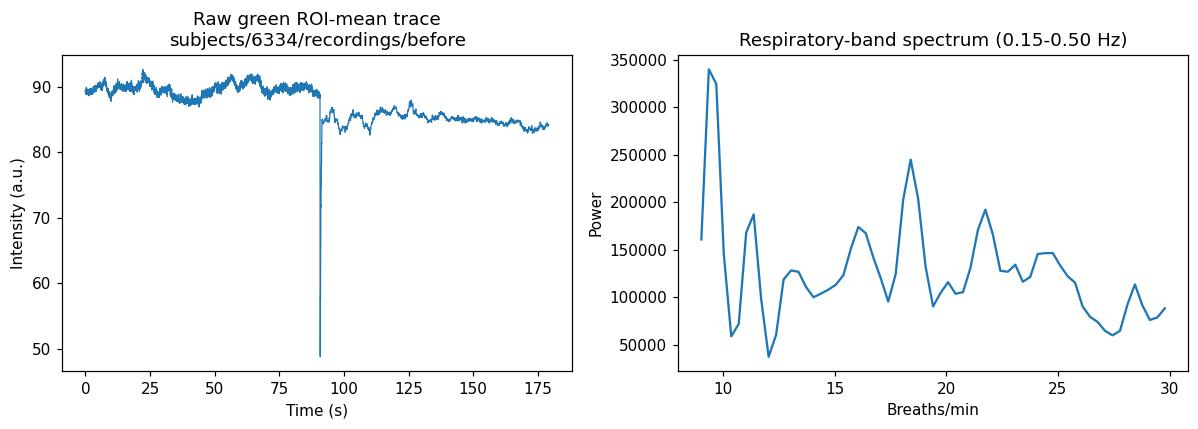

In [19]:
RIIV_SEARCH_LOW_HZ = 0.15
RIIV_SEARCH_HIGH_HZ = 0.50


def riiv_rr_estimate(roi_rgb, fps, low=RIIV_SEARCH_LOW_HZ, high=RIIV_SEARCH_HIGH_HZ, channel=1):
    """Estimates respiratory rate in breaths/min from raw ROI-mean intensity drift (RIIV).

    Averages the given RGB channel across all ROIs to build a raw intensity
    trace at the recording's video frame rate, computes its detrended Hann
    power spectrum, and returns the 3-bin-neighborhood peak frequency in the
    respiratory band as breaths/min, plus its band-power fraction. No cardiac
    bandpass is applied, since RIIV lives in the raw baseline rather than the
    pulsatile band. Returns (None, None) if the input is too short.
    """
    if roi_rgb.ndim != 3 or roi_rgb.shape[0] < 8:
        return None, None
    trace = roi_rgb[:, :, channel].mean(axis=1).astype(np.float64)
    freqs, power = hann_power_spectrum(trace, fps, remove_trend=True)
    if len(freqs) == 0:
        return None, None
    peak_hz, frac = band_peak_neighborhood(freqs, power, low, high, neighborhood_bins=1)
    if peak_hz is None:
        return None, None
    return peak_hz * 60.0, frac


def summarize_agreement(rows, estimate_label="estimate"):
    """Prints a per-recording agreement table and summary statistics against the clinical label.

    Expects rows of (name, state, rr_clinical, rr_estimate, frac), where
    rr_estimate may be None. Prints mean absolute error, agreement fractions
    within +/-2 and +/-3 br/min, and the Pearson correlation, computed only
    over recordings with a valid estimate.
    """
    print(f"{'recording':38s} {'state':8s} {'clinical':>8s} {estimate_label:>7s} {'frac':>6s} {'|diff|':>7s}")
    diffs, est_vals, clin_vals = [], [], []
    for name, state, rr_clinical, rr_est, frac in rows:
        if rr_est is not None:
            diff = abs(rr_est - rr_clinical)
            diffs.append(diff)
            est_vals.append(rr_est)
            clin_vals.append(rr_clinical)
            print(f"{name:38s} {state:8s} {rr_clinical:8.1f} {rr_est:7.1f} {frac:6.2f} {diff:7.1f}")
        else:
            print(f"{name:38s} {state:8s} {rr_clinical:8.1f} {'n/a':>7s} {'n/a':>6s} {'n/a':>7s}")

    n_valid = len(diffs)
    print(f"\nValid {estimate_label} estimates: {n_valid}/{len(rows)}")
    if n_valid >= 2:
        diffs_arr = np.array(diffs)
        mae = diffs_arr.mean()
        within2 = (diffs_arr <= 2).mean()
        within3 = (diffs_arr <= 3).mean()
        print(f"MAE: {mae:.2f} br/min")
        print(f"Within +/-2 br/min: {within2:.0%}   Within +/-3 br/min: {within3:.0%}")
        from scipy.stats import pearsonr
        r_val, p_val = pearsonr(clin_vals, est_vals)
        print(f"Pearson r: {r_val:.3f} (p={p_val:.3g})")


with h5py.File(MCD_H5_PATH, "r") as h5:
    rows_riiv = []
    example_trace, example_fps, example_name = None, None, None
    for name, state, rr_clinical, duration_s in sample:
        g = h5[name]
        roi_rgb = g["roi_rgb"][:]
        fps = float(g.attrs["fps"])
        rr_riiv, frac = riiv_rr_estimate(roi_rgb, fps)
        rows_riiv.append((name, state, rr_clinical, rr_riiv, frac))
        if example_trace is None:
            example_trace = roi_rgb[:, :, 1].mean(axis=1).astype(np.float64)
            example_fps = fps
            example_name = name

summarize_agreement(rows_riiv, estimate_label="RIIV")

# Diagnostic plot for one representative recording
freqs, power = hann_power_spectrum(example_trace, example_fps, remove_trend=True)
band_mask = (freqs >= RIIV_SEARCH_LOW_HZ) & (freqs <= RIIV_SEARCH_HIGH_HZ)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
t = np.arange(len(example_trace)) / example_fps
axes[0].plot(t, example_trace, linewidth=0.8)
axes[0].set_title(f"Raw green ROI-mean trace\n{example_name}")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Intensity (a.u.)")

axes[1].plot(freqs[band_mask] * 60.0, power[band_mask])
axes[1].set_title("Respiratory-band spectrum (0.15-0.50 Hz)")
axes[1].set_xlabel("Breaths/min")
axes[1].set_ylabel("Power")

plt.tight_layout()
plt.show()

## Does a large intensity transient explain RIIV's poor agreement?

Tests whether recordings with a large, sudden jump in the raw green trace
(like the one visible in `subjects/6334/recordings/before` around t=90s) show
worse RIIV agreement with `bm_respiratory_rate` than recordings without one.
Quantifies each recording's largest frame-to-frame jump relative to its own
typical frame-to-frame variation (a robust ratio, not an absolute threshold,
so it adapts to each recording's own noise floor). If this ratio correlates
with RIIV error, and the low-jump half of the sample shows meaningfully
better agreement than the high-jump half, that supports the transient-
contamination explanation over a blanket "no facial respiratory signal"
conclusion.

In [20]:
def max_jump_score(trace):
    """Quantifies the largest sudden jump in a trace relative to its typical frame-to-frame variation.

    Computes the median absolute frame-to-frame difference as a robust
    baseline for ordinary variation, then returns the ratio of the single
    largest absolute frame-to-frame difference to that baseline. A large
    ratio indicates one dominant transient (e.g. an exposure jump or motion
    event) rather than smooth, continuous variation.
    """
    diffs = np.abs(np.diff(trace))
    baseline = np.median(diffs)
    if baseline == 0:
        return float("inf") if diffs.max() > 0 else 0.0
    return float(diffs.max() / baseline)


with h5py.File(MCD_H5_PATH, "r") as h5:
    jump_scores = {}
    for name, state, rr_clinical, duration_s in sample:
        trace = h5[name]["roi_rgb"][:, :, 1].mean(axis=1).astype(np.float64)
        jump_scores[name] = max_jump_score(trace)

rows_riiv_annotated = [
    (name, state, rr_clinical, rr_riiv, frac, jump_scores[name])
    for name, state, rr_clinical, rr_riiv, frac in rows_riiv
]

print(f"{'recording':38s} {'state':8s} {'clinical':>8s} {'RIIV':>6s} {'|diff|':>7s} {'jump':>8s}")
for name, state, rr_clinical, rr_riiv, frac, jump in sorted(rows_riiv_annotated, key=lambda r: r[5]):
    diff = abs(rr_riiv - rr_clinical) if rr_riiv is not None else float("nan")
    print(f"{name:38s} {state:8s} {rr_clinical:8.1f} {rr_riiv:6.1f} {diff:7.1f} {jump:8.1f}")

diffs_all = np.array([abs(r[3] - r[2]) for r in rows_riiv_annotated if r[3] is not None])
jumps_all = np.array([r[5] for r in rows_riiv_annotated if r[3] is not None])

from scipy.stats import pearsonr
r_val, p_val = pearsonr(jumps_all, diffs_all)
print(f"\nCorrelation between jump score and |RIIV - clinical|: r={r_val:.3f} (p={p_val:.3g})")

median_jump = np.median(jumps_all)
low_jump_rows = [r[:5] for r in rows_riiv_annotated if r[5] <= median_jump]
high_jump_rows = [r[:5] for r in rows_riiv_annotated if r[5] > median_jump]

print(f"\n--- Low-jump half (jump <= {median_jump:.1f}), n={len(low_jump_rows)} ---")
summarize_agreement(low_jump_rows, estimate_label="RIIV")

print(f"\n--- High-jump half (jump > {median_jump:.1f}), n={len(high_jump_rows)} ---")
summarize_agreement(high_jump_rows, estimate_label="RIIV")

recording                              state    clinical   RIIV  |diff|     jump
subjects/5644/recordings/before        before       16.0    9.6     6.4      1.9
subjects/2242/recordings/after         after        18.0   11.3     6.7      2.0
subjects/7186/recordings/after         after        19.0    9.7     9.3      2.0
subjects/5237/recordings/after         after        19.0    9.3     9.7      2.2
subjects/1259/recordings/before        before       16.0    9.3     6.7      2.2
subjects/7137/recordings/after         after        17.0   11.0     6.0      2.3
subjects/2446/recordings/after         after        19.0   11.6     7.4      2.6
subjects/6397/recordings/before        before       17.0    9.3     7.7      3.3
subjects/3194/recordings/before        before       18.0    9.7     8.3      3.4
subjects/3133/recordings/after         after        17.0   12.6     4.4      4.8
subjects/2874/recordings/after         after        22.0   19.3     2.7      5.2
subjects/6066/recordings/aft

In [21]:
riiv_values = np.array([r[3] for r in rows_riiv if r[3] is not None])
clinical_values = np.array([r[2] for r in rows_riiv if r[3] is not None])

print(f"RIIV estimates (n={len(riiv_values)}): {sorted(np.round(riiv_values, 1))}")

narrow_band = (riiv_values >= 9.0) & (riiv_values < 10.5)
print(f"Fraction landing in the narrow 9.0-10.5 br/min band: {narrow_band.mean():.0%} ({narrow_band.sum()}/{len(riiv_values)})")
print(f"Std dev of RIIV estimates: {riiv_values.std():.2f} br/min")
print(f"Std dev of clinical labels for the same recordings: {clinical_values.std():.2f} br/min")

RIIV estimates (n=30): [np.float64(9.3), np.float64(9.3), np.float64(9.3), np.float64(9.3), np.float64(9.3), np.float64(9.3), np.float64(9.4), np.float64(9.4), np.float64(9.4), np.float64(9.6), np.float64(9.6), np.float64(9.7), np.float64(9.7), np.float64(10.0), np.float64(10.0), np.float64(10.3), np.float64(10.3), np.float64(10.7), np.float64(10.9), np.float64(11.0), np.float64(11.3), np.float64(11.6), np.float64(12.1), np.float64(12.1), np.float64(12.6), np.float64(12.7), np.float64(13.0), np.float64(15.0), np.float64(15.6), np.float64(19.3)]
Fraction landing in the narrow 9.0-10.5 br/min band: 57% (17/30)
Std dev of RIIV estimates: 2.26 br/min
Std dev of clinical labels for the same recordings: 2.04 br/min


## Facial RIAV vs. the MCD clinical respiratory-rate label

Tests the third respiration mechanism — RIAV, the breath-driven rise and fall
of pulse amplitude — on the same 30-recording MCD sample, using the same
0.15-0.50 Hz search band as RSA and RIIV. Uses the cardiac-band signal
already stored per recording (`rppg_green`) rather than re-deriving it from
`roi_rgb`, and searches its analytic-signal envelope
(`scipy.signal.hilbert`, then `np.abs`) for a respiratory-band peak with the
same detrended Hann spectrum and neighborhood-peak functions already reused
for RSA and RIIV.

RIAV differs from RIIV in a way that could matter: it starts from a signal
already restricted to the 0.7-3.5 Hz cardiac band, so slow non-cardiac
artifacts (auto-exposure/gain drift, lighting, head motion) that plausibly
dominated the raw RIIV baseline are attenuated before the envelope is even
computed. If RIAV also collapses onto the same shared low-frequency cluster
seen in RIIV (~9-10.5 br/min), that would argue the artifact is more
pervasive than just the raw-baseline route; if it behaves differently, the
two routes have distinct failure modes worth separating in the writeup.

Decision rule: agreement with `bm_respiratory_rate` comparable to or better
than RSA/RIIV, with a non-negligible correlation, would justify testing on
more of the 504-recording pool. Weak/no agreement is a third honest
negative — still valid, still worth reporting precisely.

recording                              state    clinical    RIAV   frac  |diff|
subjects/6334/recordings/before        before       16.0     9.0   0.07     7.0
subjects/2242/recordings/after         after        18.0    10.0   0.12     8.0
subjects/1234/recordings/after         after        18.0    11.9   0.09     6.1
subjects/7437/recordings/after         after        24.0    10.0   0.08    14.0
subjects/3385/recordings/after         after        23.0     9.3   0.07    13.7
subjects/3194/recordings/before        before       18.0     9.3   0.08     8.7
subjects/3006/recordings/before        before       17.0    28.6   0.15    11.6
subjects/2446/recordings/after         after        19.0     9.6   0.10     9.4
subjects/7380/recordings/after         after        18.0    10.5   0.09     7.5
subjects/2161/recordings/before        before       17.0    15.6   0.11     1.4
subjects/6725/recordings/after         after        21.0    14.0   0.13     7.0
subjects/8808/recordings/after         a

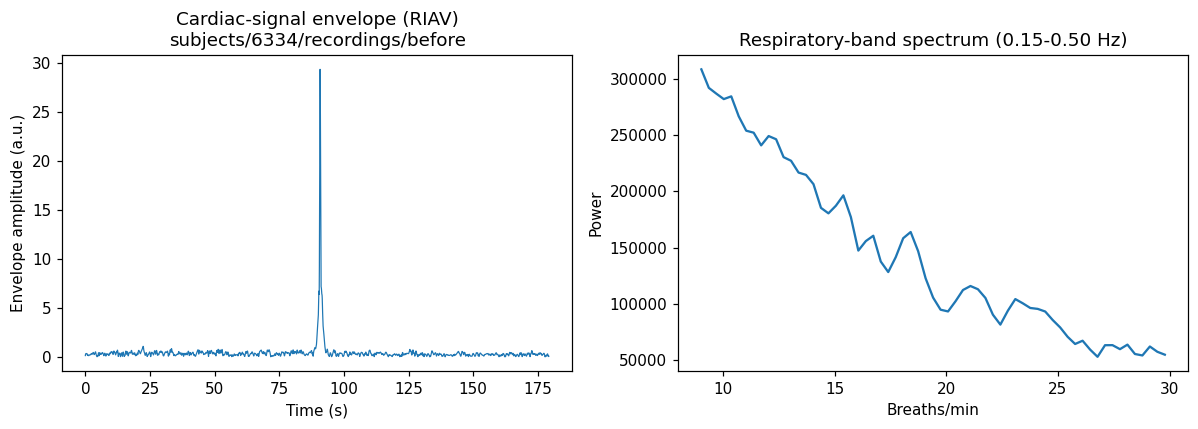

In [22]:
RIAV_SEARCH_LOW_HZ = 0.15
RIAV_SEARCH_HIGH_HZ = 0.50


def riav_rr_estimate(cardiac_signal, fps, low=RIAV_SEARCH_LOW_HZ, high=RIAV_SEARCH_HIGH_HZ):
    """Estimates respiratory rate in breaths/min from the cardiac-signal amplitude envelope (RIAV).

    Computes the analytic-signal envelope of a cardiac-band rPPG signal via
    the Hilbert transform, then applies the same detrended Hann spectrum and
    neighborhood-peak search used for RSA and RIIV to find a respiratory-band
    peak in the envelope. Returns (None, None) if the input is too short.
    """
    cardiac_signal = np.asarray(cardiac_signal, dtype=np.float64)
    if cardiac_signal.ndim != 1 or len(cardiac_signal) < 8:
        return None, None
    envelope = np.abs(hilbert(cardiac_signal))
    freqs, power = hann_power_spectrum(envelope, fps, remove_trend=True)
    if len(freqs) == 0:
        return None, None
    peak_hz, frac = band_peak_neighborhood(freqs, power, low, high, neighborhood_bins=1)
    if peak_hz is None:
        return None, None
    return peak_hz * 60.0, frac


with h5py.File(MCD_H5_PATH, "r") as h5:
    rows_riav = []
    example_env, example_fps, example_name = None, None, None
    for name, state, rr_clinical, duration_s in sample:
        g = h5[name]
        cardiac_signal = g["rppg_green"][:]
        fps = float(g.attrs["fps"])
        rr_riav, frac = riav_rr_estimate(cardiac_signal, fps)
        rows_riav.append((name, state, rr_clinical, rr_riav, frac))
        if example_env is None:
            example_env = np.abs(hilbert(np.asarray(cardiac_signal, dtype=np.float64)))
            example_fps = fps
            example_name = name

summarize_agreement(rows_riav, estimate_label="RIAV")

# Diagnostic plot for one representative recording
freqs, power = hann_power_spectrum(example_env, example_fps, remove_trend=True)
band_mask = (freqs >= RIAV_SEARCH_LOW_HZ) & (freqs <= RIAV_SEARCH_HIGH_HZ)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
t = np.arange(len(example_env)) / example_fps
axes[0].plot(t, example_env, linewidth=0.8)
axes[0].set_title(f"Cardiac-signal envelope (RIAV)\n{example_name}")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Envelope amplitude (a.u.)")

axes[1].plot(freqs[band_mask] * 60.0, power[band_mask])
axes[1].set_title("Respiratory-band spectrum (0.15-0.50 Hz)")
axes[1].set_xlabel("Breaths/min")
axes[1].set_ylabel("Power")

plt.tight_layout()
plt.show()

In [23]:
def method_summary(rows):
    """Computes MAE, agreement fractions, and Pearson r for a set of (name, state, clinical, estimate, frac) rows."""
    diffs, est_vals, clin_vals = [], [], []
    for _, _, rr_clinical, rr_est, _ in rows:
        if rr_est is not None:
            diffs.append(abs(rr_est - rr_clinical))
            est_vals.append(rr_est)
            clin_vals.append(rr_clinical)
    if len(diffs) < 2:
        return None
    diffs_arr = np.array(diffs)
    from scipy.stats import pearsonr
    r_val, p_val = pearsonr(clin_vals, est_vals)
    return {
        "n_valid": len(diffs),
        "mae": diffs_arr.mean(),
        "within2": (diffs_arr <= 2).mean(),
        "within3": (diffs_arr <= 3).mean(),
        "r": r_val,
        "p": p_val,
    }


print(f"{'method':8s} {'n':>3s} {'MAE':>6s} {'w/-2':>6s} {'w/-3':>6s} {'r':>7s} {'p':>7s}")
for label, rows_set in [("RSA", rows), ("RIIV", rows_riiv), ("RIAV", rows_riav)]:
    s = method_summary(rows_set)
    print(f"{label:8s} {s['n_valid']:3d} {s['mae']:6.2f} {s['within2']:6.0%} {s['within3']:6.0%} {s['r']:7.3f} {s['p']:7.3f}")

method     n    MAE   w/-2   w/-3       r       p
RSA       30   4.81    27%    43%  -0.041   0.832
RIIV      30   7.57     3%    10%   0.212   0.261
RIAV      30   8.42     3%     3%  -0.053   0.781


## RIIV at full scale, with and without artifact exclusion

Tests the two open explanations for RIIV's null result together: whether the
full 504-recording MCD pool (rather than the n=30 sanity check) reveals a
real correlation with `bm_respiratory_rate` that n=30 lacked the power to
detect, and whether excluding the most visibly contaminated recordings (by
the same jump-score metric used earlier, now applied as a filter rather than
a correlate) improves agreement. RIIV is used here rather than RSA/RIAV
because it was the only one of the three with a non-zero point-estimate
correlation (r=0.212) worth re-checking at scale; the same recipe can be
repeated for the others afterward if useful.

This is a different question from the earlier, already-falsified "isolated
jump explains per-recording error" test — that asked whether jump score
predicts *which* recordings are wrong. This asks whether the most
contaminated recordings, as a group, add enough aggregate noise to mask a
real correlation that a much larger, cleaner sample could reveal. Reports the
full-pool and cleaned-pool results side by side so scale and exclusion aren't
conflated, and treats agreement between both as more convincing than either
alone.

In [24]:
RIIV_ARTIFACT_EXCLUDE_FRACTION = 0.20  # drop the most-contaminated 20% by jump score; first-pass choice

with h5py.File(MCD_H5_PATH, "r") as h5:
    all_groups = find_recording_groups(h5, needs=("rr_intervals",), limit=10_000)

    full_candidates = []
    for name in all_groups:
        g = h5[name]
        valid = bool(g.attrs.get("bm_respiratory_rate_valid", False))
        tier = g.attrs.get("bm_respiratory_rate_tier", "")
        if "fps" in g.attrs and "reference_signal" in g:
            duration_s = len(g["reference_signal"]) / g.attrs["fps"]
        else:
            duration_s = float(np.sum(g["rr_intervals"][:])) / 1000.0
        if valid and tier == "tier_1_confident" and duration_s >= 150.0:
            state = name.rsplit("/", 1)[-1]
            full_candidates.append((name, state, float(g.attrs["bm_respiratory_rate"]), duration_s))

    print(f"Full candidate pool: {len(full_candidates)}")

    rows_riiv_full = []
    for name, state, rr_clinical, duration_s in full_candidates:
        g = h5[name]
        roi_rgb = g["roi_rgb"][:]
        fps = float(g.attrs["fps"])
        rr_riiv, frac = riiv_rr_estimate(roi_rgb, fps)
        trace = roi_rgb[:, :, 1].mean(axis=1).astype(np.float64)
        jump = max_jump_score(trace)
        rows_riiv_full.append((name, state, rr_clinical, rr_riiv, frac, jump))

print(f"\n=== Full pool (n={len(rows_riiv_full)}) ===")
summarize_agreement([r[:5] for r in rows_riiv_full], estimate_label="RIIV")

jumps = np.array([r[5] for r in rows_riiv_full])
cutoff = np.quantile(jumps, 1.0 - RIIV_ARTIFACT_EXCLUDE_FRACTION)
cleaned_rows = [r[:5] for r in rows_riiv_full if r[5] <= cutoff]

print(f"\n=== Cleaned pool: dropping top {RIIV_ARTIFACT_EXCLUDE_FRACTION:.0%} by jump score (cutoff={cutoff:.1f}), n={len(cleaned_rows)} ===")
summarize_agreement(cleaned_rows, estimate_label="RIIV")

Full candidate pool: 504

=== Full pool (n=504) ===
recording                              state    clinical    RIIV   frac  |diff|
subjects/1020/recordings/before        before       18.0    10.0   0.11     8.0
subjects/1035/recordings/after         after        18.0    19.3   0.10     1.3
subjects/1035/recordings/before        before       18.0     9.1   0.08     8.9
subjects/1091/recordings/after         after        19.0     9.3   0.10     9.7
subjects/1091/recordings/before        before       16.0     9.3   0.08     6.7
subjects/1113/recordings/after         after        20.0    11.0   0.17     9.0
subjects/1115/recordings/after         after        19.0     9.0   0.07    10.0
subjects/1149/recordings/before        before       18.0    10.0   0.30     8.0
subjects/1156/recordings/before        before       16.0    17.0   0.09     1.0
subjects/1180/recordings/before        before       16.0     9.1   0.12     6.9
subjects/1213/recordings/before        before       16.0     9.6   0

## Internal consistency: do facial RIIV and beat-timing RSA agree with each other?

Tests whether the two respiration estimates that are both concurrent with the
video and both already in the local file — facial RIIV (raw green `roi_rgb`,
full ~180 s) and RSA (`rr_intervals` beat timing, ~29 s) — agree with each
other across recordings, independent of the external `db.csv` clinical label
that both previously failed against. The logic: if two concurrent modalities
from the same recording cannot agree on the respiratory band, a third
concurrent reference (ECG-derived respiration, obtainable only by
re-downloading the raw dataset) is less likely to rescue the facial signal; if
they show even weak agreement, that is real evidence the facial signal carries
breathing and justifies the download.

Reuses `rsa_rr_estimate` and `riiv_rr_estimate` unchanged. Two caveats shape
the reading. First, RIIV spans the full recording while RSA spans only its
~29 s of beat data, and their exact overlap is unknown, so the comparison
leans on within-recording RR stationarity. Second, the clinical labels' own
spread is narrow (SD ≈ 2 br/min), so per-method noise easily washes out a real
correlation. Both caveats make the test asymmetric: a clear positive is strong
evidence, a null is weak evidence (window mismatch, short-RSA power, or
range washout — not proof the signal is absent). Stratified by state because
post-exercise "after" recordings may have RR drifting during recovery, which
would violate stationarity; the resting "before" subset is the cleaner test.

Recordings with both RSA and RIIV valid: 504

--- RIIV vs RSA (the internal-consistency test) ---
all      n=504  MAE=6.10  within3=35%  Pearson=-0.010(p=0.82)  Spearman=-0.023(p=0.61)
before   n=257  MAE=5.31  within3=38%  Pearson=-0.028(p=0.66)  Spearman=-0.043(p=0.49)
after    n=247  MAE=6.93  within3=32%  Pearson=+0.010(p=0.88)  Spearman=+0.008(p=0.9)

--- Anchors: how each modality relates to the weak clinical label ---
RSA  vs clinical  Pearson=+0.162
RIIV vs clinical  Pearson=-0.013


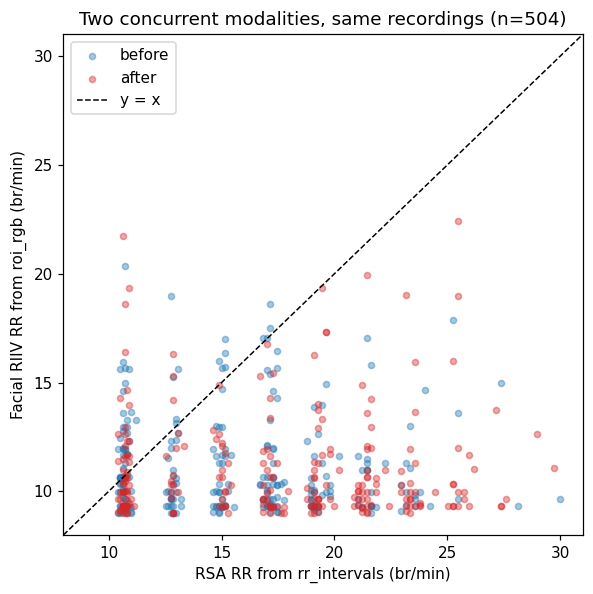

In [25]:
def report_pair(label, rsa_v, riiv_v):
    """Prints agreement statistics between two paired respiratory-rate estimate arrays."""
    if len(rsa_v) < 3:
        print(f"{label:8s} n={len(rsa_v):3d}  (too few for correlation)")
        return
    d = np.abs(riiv_v - rsa_v)
    rp, pp = pearsonr(rsa_v, riiv_v)
    rs, ps = spearmanr(rsa_v, riiv_v)
    print(f"{label:8s} n={len(rsa_v):3d}  MAE={d.mean():4.2f}  within3={np.mean(d <= 3):3.0%}  "
          f"Pearson={rp:+.3f}(p={pp:.2g})  Spearman={rs:+.3f}(p={ps:.2g})")


with h5py.File(MCD_H5_PATH, "r") as h5:
    all_groups = find_recording_groups(h5, needs=("rr_intervals",), limit=10_000)
    paired = []
    for name in all_groups:
        g = h5[name]
        valid = bool(g.attrs.get("bm_respiratory_rate_valid", False))
        tier = g.attrs.get("bm_respiratory_rate_tier", "")
        if "fps" in g.attrs and "reference_signal" in g:
            duration_s = len(g["reference_signal"]) / g.attrs["fps"]
        else:
            duration_s = float(np.sum(g["rr_intervals"][:])) / 1000.0
        if not (valid and tier == "tier_1_confident" and duration_s >= 150.0):
            continue
        fps = float(g.attrs["fps"])
        rr_rsa, _ = rsa_rr_estimate(g["rr_intervals"][:])
        rr_riiv, _ = riiv_rr_estimate(g["roi_rgb"][:], fps)
        state = name.rsplit("/", 1)[-1]
        paired.append((state, float(g.attrs["bm_respiratory_rate"]), rr_rsa, rr_riiv))

both = [(st, c, s, v) for (st, c, s, v) in paired if s is not None and v is not None]
states = np.array([p[0] for p in both])
clin = np.array([p[1] for p in both])
rsa = np.array([p[2] for p in both])
riiv = np.array([p[3] for p in both])

print(f"Recordings with both RSA and RIIV valid: {len(both)}\n")
print("--- RIIV vs RSA (the internal-consistency test) ---")
report_pair("all", rsa, riiv)
report_pair("before", rsa[states == "before"], riiv[states == "before"])
report_pair("after", rsa[states == "after"], riiv[states == "after"])

print("\n--- Anchors: how each modality relates to the weak clinical label ---")
print(f"RSA  vs clinical  Pearson={pearsonr(clin, rsa)[0]:+.3f}")
print(f"RIIV vs clinical  Pearson={pearsonr(clin, riiv)[0]:+.3f}")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
for st, color in [("before", "tab:blue"), ("after", "tab:red")]:
    m = states == st
    ax.scatter(rsa[m], riiv[m], s=16, alpha=0.4, color=color, label=st)
lims = [min(rsa.min(), riiv.min()) - 1, max(rsa.max(), riiv.max()) + 1]
ax.plot(lims, lims, "k--", linewidth=1, label="y = x")
ax.set_xlabel("RSA RR from rr_intervals (br/min)")
ax.set_ylabel("Facial RIIV RR from roi_rgb (br/min)")
ax.set_title(f"Two concurrent modalities, same recordings (n={len(both)})")
ax.set_xlim(lims); ax.set_ylim(lims); ax.legend()
plt.tight_layout()
plt.show()

## Conclusion — NB_P3_01 Respiratory-Rate Exploration

**Question.** Can respiratory rate be estimated from CRVSE's facial rPPG
signals, with a checkable ground truth, using classical spectral methods?

**What was tested.** The investigation followed the physiology → signal →
limitations → experiment → interpret loop across two datasets and all three
respiration-modulation mechanisms. On UBFC-rPPG, RSA from beat-timing was
tested as a ground truth and failed a permutation/surrogate significance test
(~50–70 s recordings, insufficient power, an apparently aroused cohort). The
work then pivoted to MCD-rPPG, which was found to carry an explicit clinical
`bm_respiratory_rate` label. Against that label, three independent estimators
were tested: RSA (`rr_intervals`), RIIV (raw green `roi_rgb`), and RIAV
(`rppg_green` envelope). RIIV was re-run at full scale (n=504) with and without
artifact exclusion. Finally, an internal-consistency test compared facial RIIV
against concurrent beat-timing RSA directly.

**Results.** All estimators correlated near zero with the clinical label
(r = −0.04 / +0.21 / −0.05 at n=30; RIIV at n=504: r = −0.01, and r = 0.006
after excluding the most artifact-contaminated 20%). MAE ranged 4.8–8.4 br/min;
agreement within ±3 br/min never exceeded ~43% (RSA) and was ~10% for the
facial methods. The internal-consistency test was decisive: RSA carried a weak
but statistically real thread of respiratory signal (RSA vs clinical
r = +0.16 at n=504, p ≈ 0.0002), yet facial RIIV agreed with neither the
clinical label nor the concurrent RSA — including the resting "before" subset
(r = −0.03, p = 0.66).

**Root cause.** Inspection of the preprocessing notebook (NB_P2_06) confirmed
`roi_rgb` is stored raw, so the facial negative is a real signal-level result
rather than filtered-out data. The clinical label originates from the dataset's
`db.csv` as a non-concurrent scalar (whole numbers, SD ≈ 2 br/min), a weak
validation target. But the internal-consistency test moves the conclusion past
the reference problem: a concurrent physiological modality that demonstrably
carries real respiratory signal (RSA) shows zero agreement with the facial
signal. The binding limitation is the facial camera signal itself, not only the
choice of ground truth.

**What the evidence supports.** With CRVSE's current data, the facial rPPG
signal does not carry recoverable respiratory-rate information detectable by
these classical spectral methods. The beat-timing (RSA) channel carries a trace
of real signal but is far too weak to be usable and depends on beat detection
the live path cannot perform reliably.

**What the evidence does NOT support.** It does not prove facial RR is
impossible in general — RIIV/RIAV/RSA are established in the literature. It
shows the signal is not recoverable *from this HR-optimized data, against these
references, with this extraction*. It does not rule out that a purpose-built
capture (concurrent respiration-belt reference, exposure-locked camera,
respiration-optimized ROIs, 60 s windows) could surface a weak signal under
ideal conditions.

**Decision.** This exploration is closed as a documented, well-powered honest
negative. Respiratory rate remains out of scope for the CRVSE product;
spectral-consensus HR stays the only product-grade vital. Any revisit is a new
phase gated on solving the acquisition/ground-truth problem first, not on
further spectral variants of the current data. Ranked forward options are
recorded in `CRVSE_RR_exploration_plan.md`, Section 9.